### Importar librerías

In [2]:
import tensorflow as tf
from tensorflow import keras
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt

from tensorflow.keras.utils import plot_model
from tensorflow.keras.callbacks import EarlyStopping

### Cargar el dataset MNIST (dígitos escritos a mano)

In [3]:
# Importar el dataset
digits_data = keras.datasets.mnist

# Cargar datos de entrenamiento y prueba
(train_images, train_labels), (test_images, test_labels) = digits_data.load_data()

### Crear nombres de las clases

In [4]:
class_names = [str(i) for i in range(10)]
class_names

['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

### Mostrar una imagen de ejemplo (tamaño original 28x28)

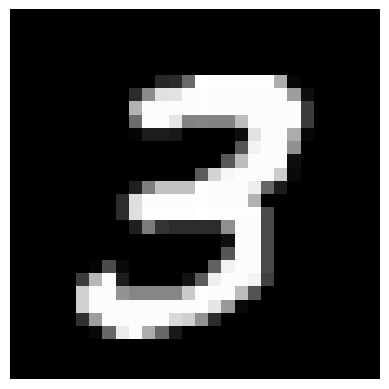

In [5]:
plt.imshow(train_images[7], cmap="gray")
plt.grid(False)
plt.axis("off")
plt.show()

### Verificar el tamaño del dataset original

In [6]:
train_images.shape, test_images.shape

((60000, 28, 28), (10000, 28, 28))

### Distribución de clases

In [7]:
df = pd.DataFrame(np.unique(train_labels, return_counts=True)).T
df.columns = ["Label", "Count"]
df

,Label,Count
0,0,5923
1,1,6742
2,2,5958
3,3,6131
4,4,5842
5,5,5421
6,6,5918
7,7,6265
8,8,5851
9,9,5949


### Redimensionar las imágenes a 16x16

El modelo se va a usar después en una GUI donde la persona dibuja el dígito en un canvas de 16x16 pixeles,
así que redimensionamos el dataset de 28x28 a 16x16 para que la entrada del modelo coincida con la entrada real que vamos a mandarle desde la web.

In [8]:
IMG_SIZE = 16

def resize_images(images):
    images = images.astype("float32")
    images = images[..., np.newaxis]  # (N, 28, 28, 1)
    images = tf.image.resize(images, (IMG_SIZE, IMG_SIZE), method="bilinear")
    images = images.numpy().squeeze(-1)  # (N, 16, 16)
    return images

train_images = resize_images(train_images)
test_images = resize_images(test_images)

train_images.shape, test_images.shape

((60000, 16, 16), (10000, 16, 16))

### Mostrar la misma imagen ya en 16x16 (para comparar contra la de 28x28)

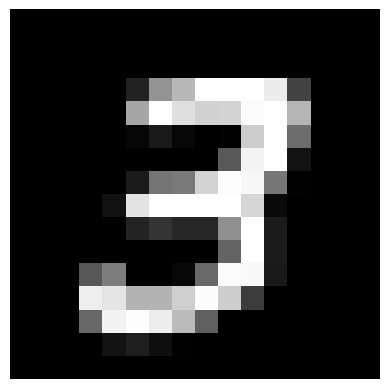

In [9]:
plt.imshow(train_images[7], cmap="gray")
plt.grid(False)
plt.axis("off")
plt.show()

### Mostrar las primeras 16 imágenes en 16x16

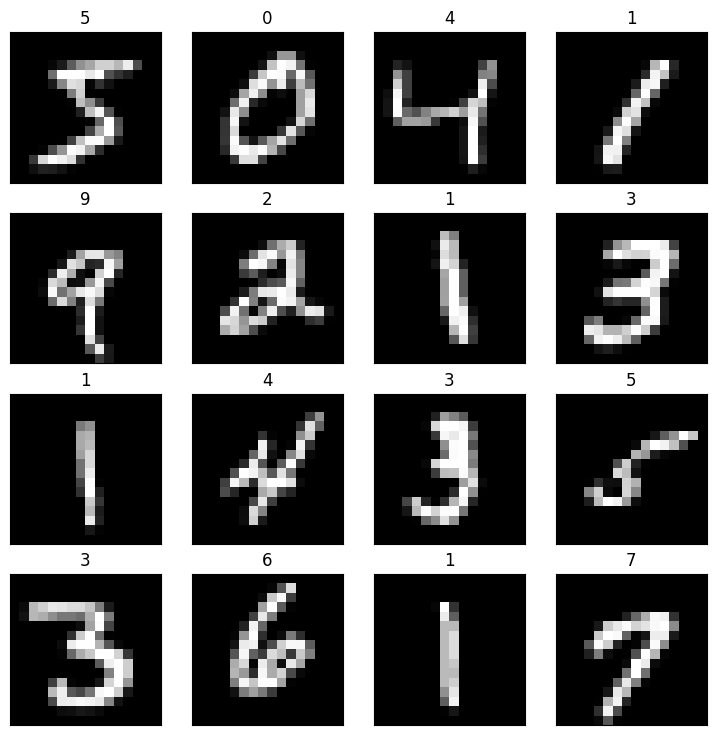

In [10]:
plt.figure(figsize=(9,9))

for i in range(16):
    plt.subplot(4,4,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i], cmap="gray")
    plt.title(class_names[train_labels[i]])

plt.show()

### Normalizar las imágenes

Escalamos de 0-255 a 0-1, igual que en escala de grises normalizada.

In [11]:
train_images = train_images / 255.0
test_images = test_images / 255.0

train_images.min(), train_images.max()

(np.float32(0.0), np.float32(1.0))

### Crear la red neuronal

- Capa de entrada: `Flatten` con la forma que depende del número de pixeles (16x16 = 256 entradas).
- Capas ocultas: `Dense` con activación `relu` (cantidad de capas y neuronas libre).
- Capa de salida: `Dense(10, activation="softmax")`, una neurona por cada dígito (0-9).

In [12]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(IMG_SIZE, IMG_SIZE)),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

c:\Users\maria\OneDrive\Documentos\TecNM ISC\Inteligencia Artificial\summervenv\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,802 (163.29 KB)

 Trainable params: 41,802 (163.29 KB)

 Non-trainable params: 0 (0.00 B)

### Compilar el modelo

Como es clasificación multiclase con etiquetas como enteros (0-9, no one-hot), usamos `sparse_categorical_crossentropy`.
El optimizador es `Adam` (aquí se deja el learning rate libre para ajustarlo).

In [14]:
optimizer = keras.optimizers.Adam(learning_rate=0.001)

model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

### Ver resumen del modelo

In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,802 (163.29 KB)

 Trainable params: 41,802 (163.29 KB)

 Non-trainable params: 0 (0.00 B)

### Dibujar arquitectura

In [16]:
plot_model(
    model,
    to_file="model_plot.png",
    show_shapes=True,
    show_layer_names=True
)

You must install pydot (`pip install pydot`) for `plot_model` to work.


### Configurar Early Stopping

Detiene el entrenamiento si la pérdida de validación deja de mejorar, y restaura los mejores pesos encontrados.

In [17]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

### Entrenar el modelo

In [18]:
history = model.fit(
    train_images,
    train_labels,
    epochs=50,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9073 - loss: 0.3257 - val_accuracy: 0.9553 - val_loss: 0.1582
Epoch 2/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9592 - loss: 0.1357 - val_accuracy: 0.9650 - val_loss: 0.1180
Epoch 3/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9705 - loss: 0.0978 - val_accuracy: 0.9681 - val_loss: 0.1083
Epoch 4/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9763 - loss: 0.0759 - val_accuracy: 0.9730 - val_loss: 0.0968
Epoch 5/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9812 - loss: 0.0614 - val_accuracy: 0.9730 - val_loss: 0.0910
Epoch 6/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9839 - loss: 0.0509 - val_accuracy: 0.9749 - val_loss: 0.0908
Epoch 7/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9867 - loss: 0.0423 - val_accuracy: 0.9720 - val_loss: 0.1067
Epoch 8/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9888 - loss: 0.0352 - 

### Graficar la precisión

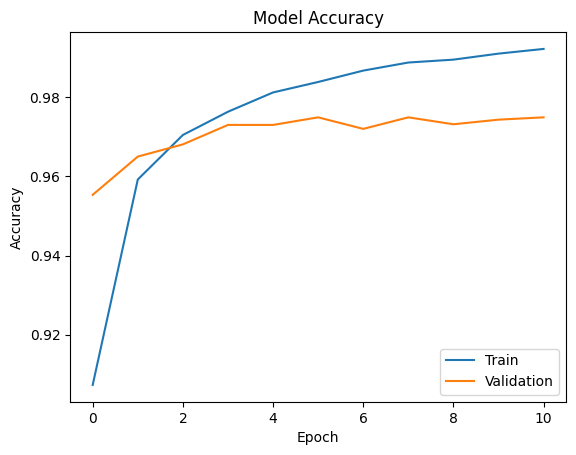

In [19]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["Train", "Validation"], loc="lower right")
plt.show()

### Graficar la pérdida

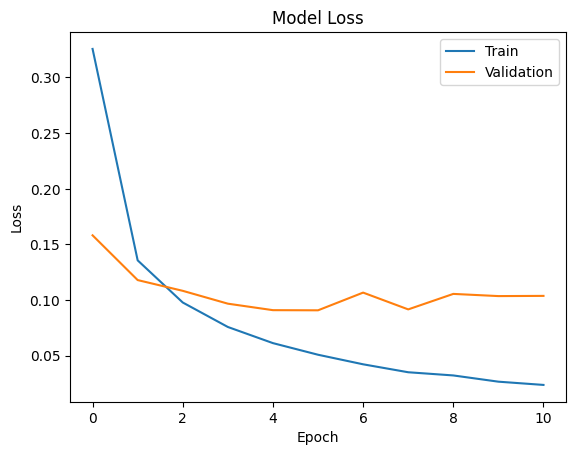

In [20]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend(["Train", "Validation"], loc="upper right")
plt.show()

### Evaluar el modelo

In [21]:
test_loss, test_acc = model.evaluate(test_images, test_labels)

print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9778 - loss: 0.0724
Test Accuracy: 0.9778000116348267


### Realizar predicciones

In [22]:
predictions = model.predict(test_images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


### Ver las posibilidades de la primera imagen

In [23]:
predictions[0].round(2)

array([0., 0., 0., 0., 0., 0., 0., 1., 0., 0.], dtype=float32)

### Comparar predicción con etiqueta real

In [24]:
print("Predicción:", np.argmax(predictions[0]))
print("Etiqueta real:", test_labels[0])

Predicción: 7
Etiqueta real: 7


### Mostrar 16 predicciones aleatorias

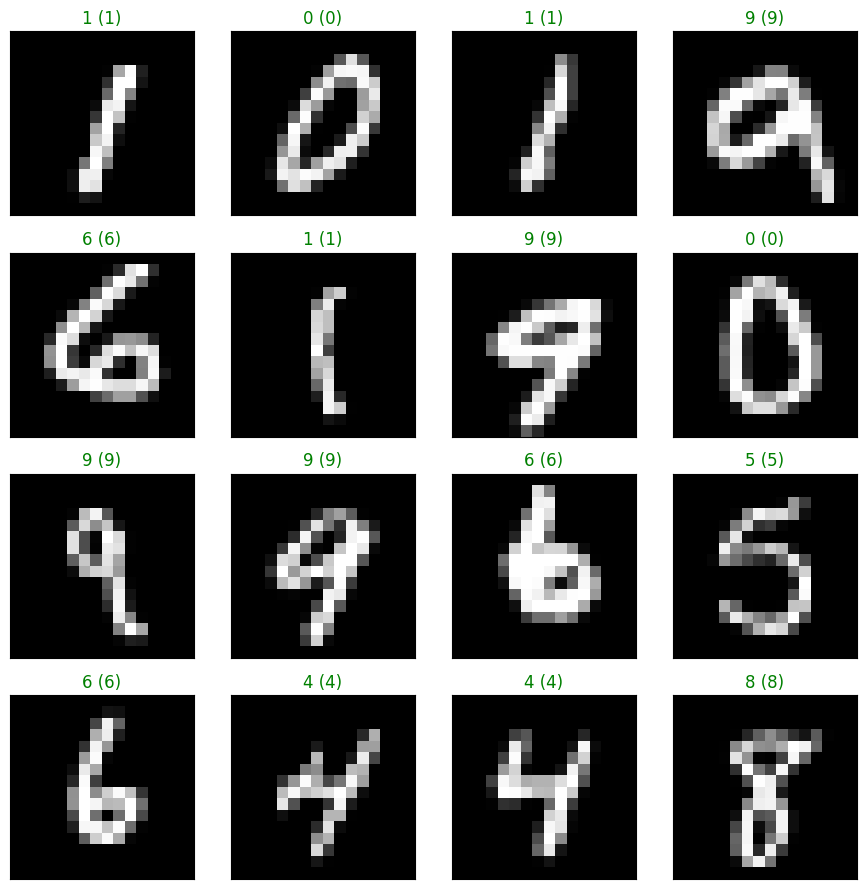

In [25]:
figure = plt.figure(figsize=(9,9))

indices = np.random.choice(
    test_images.shape[0],
    size=16,
    replace=False
)

for i, index in enumerate(indices):

    ax = figure.add_subplot(4,4,i+1)

    ax.set_xticks([])
    ax.set_yticks([])

    ax.imshow(test_images[index], cmap="gray")

    predict_index = np.argmax(predictions[index])
    true_index = test_labels[index]

    ax.set_title(
        f"{class_names[predict_index]} ({class_names[true_index]})",
        color="green" if predict_index == true_index else "red"
    )

plt.tight_layout()
plt.show()

### Guardar el modelo en formato .h5

Este archivo `.h5` es el que vamos a subir a GitHub junto con `app.py` y el resto de archivos para desplegar en Render.

In [26]:
model.save("digit_model.h5")
print("Modelo guardado como digit_model.h5")

Modelo guardado como digit_model.h5


### Guardar las clases (labels) en un archivo aparte

Guardamos también un pequeño archivo con las clases y el tamaño de imagen esperado, para que la app web (`app.py`) sepa cómo preprocesar el dibujo del usuario antes de mandarlo al modelo.

In [27]:
import json

model_config = {
    "img_size": IMG_SIZE,
    "class_names": class_names
}

with open("labels.json", "w") as f:
    json.dump(model_config, f, indent=2)

print("Archivo labels.json guardado")

Archivo labels.json guardado
